In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv
/kaggle/input/datasets/lukajincharadze/pandas-data/noc_regions.csv
/kaggle/input/datasets/lukajincharadze/pandas-data/olympics-data.xlsx
/kaggle/input/datasets/lukajincharadze/pandas-data/results.parquet
/kaggle/input/datasets/lukajincharadze/pandas-data/bios.csv
/kaggle/input/datasets/lukajincharadze/pandas-data/coffee.csv
/kaggle/input/datasets/lukajincharadze/pandas-data/results.csv


In [2]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 689.0 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 37.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 4.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import dagshub
import sys
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

sys.path.append('/kaggle/usr/lib/my_preprocessing_classes')
import my_preprocessing_classes as mpc

dagshub.init(repo_owner='aleko-mamukashvili', repo_name='-IEEE-CIS-Fraud-Detection.', mlflow=True)
mlflow.set_experiment("Random_Forest_Experiment")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=38ab0891-bb16-46e2-a539-48b2e327a348&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=c5e1286f8f5bb21ba1e610ff2b0196638ab52fc07faf3a86e7660e709ee054eb




Accessing as aleko-mamukashvili

Initialized MLflow to track repo "aleko-mamukashvili/-IEEE-CIS-Fraud-Detection."

Repository aleko-mamukashvili/-IEEE-CIS-Fraud-Detection. initialized!

2026/05/06 18:04:58 INFO mlflow.tracking.fluent: Experiment with name 'Random_Forest_Experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/7ec72c9373c348c8a18c19f3827a0630', creation_time=1778090698746, experiment_id='6', last_update_time=1778090698746, lifecycle_stage='active', name='Random_Forest_Experiment', tags={}, trace_location=None, workspace='default'>

In [13]:
def advanced_engineering(df):
    df = df.copy()
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
    df['Amt_to_mean_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('mean')
    df['Amt_to_std_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('std')
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)
    df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    df['P_emaildomain'] = df['P_emaildomain'].fillna('missing')
    df['P_email_suffix'] = df['P_emaildomain'].map(lambda x: str(x).split('.')[-1])
    return df

path = '/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv'
train_df = pd.read_csv(path, nrows=100000)

X = train_df.drop('isFraud', axis=1)
y = train_df['isFraud']

X_eng = advanced_engineering(X)


X_train, X_val, y_train, y_val = train_test_split(X_eng, y, test_size=0.2, random_state=42, stratify=y)

print("✅ ყველაფერი მზადაა, შეგიძლია გადახვიდე RF ტრენინგზე!")

✅ ყველაფერი მზადაა, შეგიძლია გადახვიდე RF ტრენინგზე!


In [14]:
mlflow.set_experiment("Random_Forest_Experiment")
rf_pipeline = Pipeline([
    ('cleaner', mpc.FraudDataCleaner(drop_threshold=0.9)),
    ('encoder', mpc.FraudEncoder()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=20,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

with mlflow.start_run(run_name="RF_Base_Experiment"):
    rf_pipeline.fit(X_train, y_train)
    
    train_probs = rf_pipeline.predict_proba(X_train)[:, 1]
    val_probs = rf_pipeline.predict_proba(X_val)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    mlflow.log_params(rf_pipeline.named_steps['model'].get_params())
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    
    print(f"🌲 Train AUC: {train_auc:.4f}")
    print(f"🚀 Val AUC: {val_auc:.4f}")
    print(f"📊 Gap: {train_auc - val_auc:.4f}")

🌲 Train AUC: 0.9296
🚀 Val AUC: 0.8808
📊 Gap: 0.0488
🏃 View run RF_Base_Experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/6/runs/f424e5ad7b574d8eb77b7c3d22ac8bb7
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/6


/kaggle/usr/lib/notebooks/alekomamukashvili/my_preprocessing_classes/my_preprocessing_classes.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X_copy.fillna(-999)
/tmp/ipykernel_57/554451977.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')


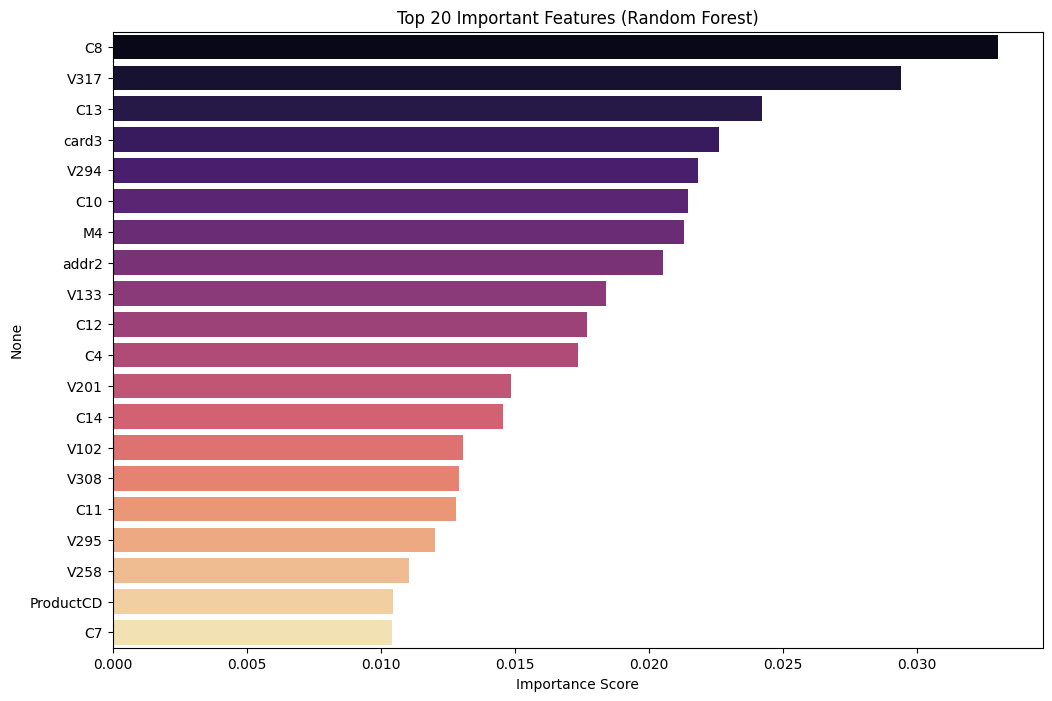

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_data = X_train.head(1)
transformed_sample = rf_pipeline.named_steps['cleaner'].transform(sample_data)
transformed_sample = rf_pipeline.named_steps['encoder'].transform(transformed_sample)

feature_names = transformed_sample.columns

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')
plt.title('Top 20 Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

In [22]:
def super_advanced_engineering(df):
    df = df.copy()
    
    df['TransactionAmt_Log'] = np.log1p(df['TransactionAmt'])
    
    df['hour'] = (df['TransactionDT'] // 3600) % 24

    df['card1_count'] = df.groupby('card1')['TransactionAmt'].transform('count')
    
    df['Amt_to_mean_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('mean')
    df['Amt_to_mean_card4'] = df['TransactionAmt'] / df.groupby('card4')['TransactionAmt'].transform('mean')
    
    df['P_emaildomain'] = df['P_emaildomain'].fillna('missing')
    
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(-999, inplace=True) # RF-ისთვის -999 ხშირად უკეთესია ვიდრე 0
    
    return df

X_eng = super_advanced_engineering(X)
X_train, X_val, y_train, y_val = train_test_split(X_eng, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
mlflow.set_experiment("Random_Forest_Experiment")

class UltimateEncoder(mpc.FraudEncoder):
    def transform(self, X):
        X = X.copy()
        obj_cols = X.select_dtypes(include=['object']).columns
        for col in obj_cols:
            X[col] = pd.factorize(X[col])[0]
        return super().transform(X)

rf_super_pipeline = Pipeline([
    ('cleaner', mpc.FraudDataCleaner(drop_threshold=0.85)),
    ('encoder', UltimateEncoder()),
    ('model', RandomForestClassifier(
        n_estimators=300,     
        max_depth=15,
        min_samples_leaf=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

with mlflow.start_run(run_name="RF_Super_Advanced"):
    rf_super_pipeline.fit(X_train, y_train)
    
    val_probs = rf_super_pipeline.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)
    
    print(f"🚀 New Validation AUC: {val_auc:.4f}")

🚀 New Validation AUC: 0.8951
🏃 View run RF_Super_Advanced at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/6/runs/19bba62e4079437d805c902190d414fd
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/6


🌲 Train AUC: 0.9752
🚀 Val AUC: 0.8951
📊 Overfitting Gap: 0.0801
🏃 View run RF_Super_Advanced_Final at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/6/runs/acf4d33aac8f486799b6ce2e301da598
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/6


/kaggle/usr/lib/notebooks/alekomamukashvili/my_preprocessing_classes/my_preprocessing_classes.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X_copy.fillna(-999)
/tmp/ipykernel_57/72793119.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='rocket')


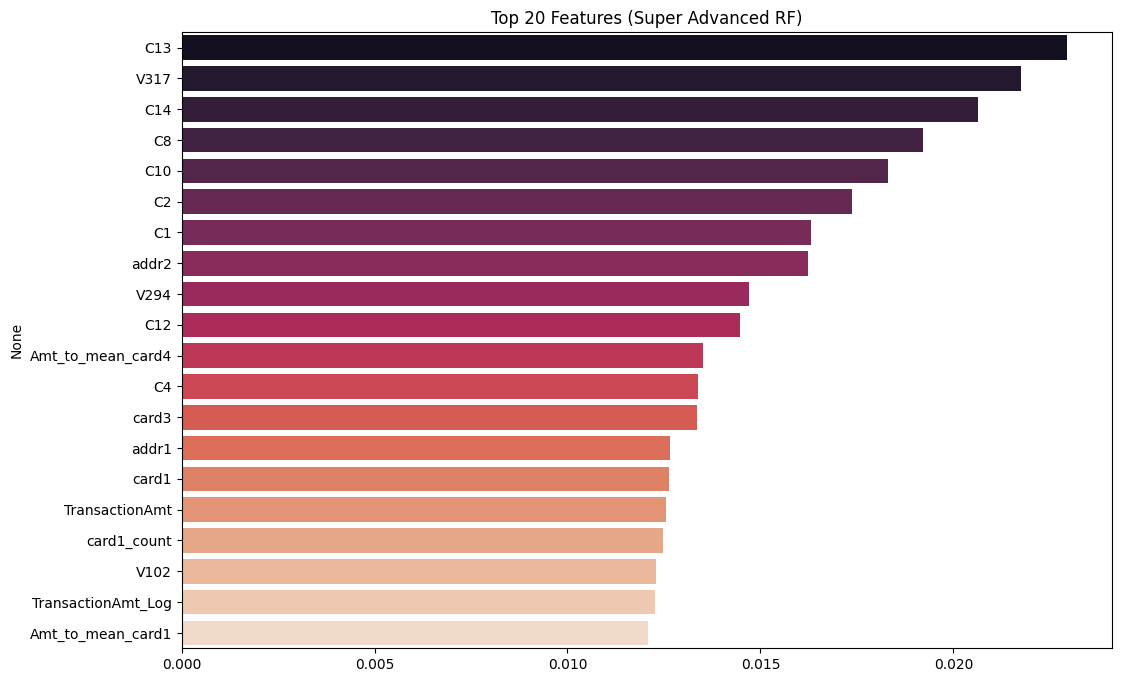

In [25]:
with mlflow.start_run(run_name="RF_Super_Advanced_Final"):
    rf_super_pipeline.fit(X_train, y_train)
    
    train_probs = rf_super_pipeline.predict_proba(X_train)[:, 1]
    val_probs = rf_super_pipeline.predict_proba(X_val)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    
    print(f"🌲 Train AUC: {train_auc:.4f}")
    print(f"🚀 Val AUC: {val_auc:.4f}")
    print(f"📊 Overfitting Gap: {train_auc - val_auc:.4f}")

sample_data = X_train.head(1)
transformed_sample = rf_super_pipeline.named_steps['cleaner'].transform(sample_data)
transformed_sample = rf_super_pipeline.named_steps['encoder'].transform(transformed_sample)
feature_names = transformed_sample.columns

importances = rf_super_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='rocket')
plt.title('Top 20 Features (Super Advanced RF)')
plt.show()